In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cobra

# Loading the model and maximal reaction activity
model = cobra.io.load_json_model('e_coli_core-1.json')

data = pd.read_csv("KEN3170_Assignment_2026_e_coli_core_expression.csv")
activities = dict(zip(data["# Reaction ID"], 
                      data[" reaction activity [mmol/gDW/h] "]))

### Task 1


a) Inside a steady-state model simulation flux values remain equal in closed linear pathways due to mass balance constraints. However, the maximal reaction activity values are approximations stemming from enzyme gene expressions, thus they do not need to correspond to an existing steady-state. For example in glycolysis, PGI has a maximal activity of 11.1, while TPI has 70 mmol/gDW/hour. When the pathway is actually used in the model, the enzyme with lowest maximal activity can limit how much flux can pass through the whole pipeline, creating a bottleneck.

b) The tool uses grey arrows to display reactions in one of two states.
1. With 0 flux signifying the reaction is within the expression dataset, however no enzyme expression was detected, so no flux can be carried.
2. No data, meaning no meaningful constraints stemming from enzyme expression could be derived. Bounds assume an arbitrary, large default values of 1000.


### Task 2

What is the lower and upper bound of EX_glc__D_e and is it in the max activities csv file?


In [35]:
reaction = model.reactions.get_by_id("EX_glc__D_e")

print(reaction.lower_bound)
print(reaction.upper_bound)
print("EX_glc__D_e" in activities)

-10.0
1000.0
False


Observations: 
As EX_glc__D_e is not in the csv file with the max activities, following function is sufficient to meet all requirements. It still has the pre existing lower bound of -10, so we set it to -1000 afterwards.


In [36]:
# Changing values to -value and value
for reaction in model.reactions:
    if reaction.id in activities:

        value = activities[reaction.id]

        if reaction.reversibility:
            reaction.lower_bound = -value
            reaction.upper_bound = value
        else:
            reaction.upper_bound = value

# Remove bound on glucose exchange
model.reactions.get_by_id("EX_glc__D_e").lower_bound = -1000

In [37]:
# Making sure that lower bound has not changed
reaction = model.reactions.get_by_id("ATPM")

print(reaction.lower_bound)
print(reaction.upper_bound)

8.39
1000.0


In [38]:
#print all bounds

print(len(model.reactions))
for reaction in model.reactions:
    print(reaction.id, "| lower bound: ", reaction.lower_bound, "AND upper bound: ", reaction.upper_bound)

95
PFK | lower bound:  0.0 AND upper bound:  13.1
PFL | lower bound:  0.0 AND upper bound:  0.0
PGI | lower bound:  -11.1 AND upper bound:  11.1
PGK | lower bound:  -24.0 AND upper bound:  24.0
PGL | lower bound:  0.0 AND upper bound:  7.3
ACALD | lower bound:  -0.0 AND upper bound:  0.0
AKGt2r | lower bound:  -0.0 AND upper bound:  0.0
PGM | lower bound:  -21.7 AND upper bound:  21.7
PIt2r | lower bound:  -5.2 AND upper bound:  5.2
ALCD2x | lower bound:  -0.0 AND upper bound:  0.0
ACALDt | lower bound:  -1000.0 AND upper bound:  1000.0
ACKr | lower bound:  -2.5 AND upper bound:  2.5
PPC | lower bound:  0.0 AND upper bound:  3.6
ACONTa | lower bound:  -21.4 AND upper bound:  21.4
ACONTb | lower bound:  -21.4 AND upper bound:  21.4
ATPM | lower bound:  8.39 AND upper bound:  1000.0
PPCK | lower bound:  0.0 AND upper bound:  13.3
ACt2r | lower bound:  -3.6 AND upper bound:  3.6
PPS | lower bound:  0.0 AND upper bound:  3.1
ADK1 | lower bound:  -27.4 AND upper bound:  27.4
AKGDH | lower b

### Task 3

In [11]:
# Verify that correct objective function is set
print(model.objective)

Maximize
1.0*BIOMASS_Ecoli_core_w_GAM - 1.0*BIOMASS_Ecoli_core_w_GAM_reverse_712e5


In [12]:
# Perform FBA with cobrapy optimization tool, check the objective value
solution = model.optimize()

print("Max biomass production rate: ", solution.objective_value)
print("Glucose uptake: ", solution.fluxes["EX_glc__D_e"])
print("Glucose uptake bound: ", model.reactions.get_by_id("EX_glc__D_e").lower_bound)

Max biomass production rate:  0.8732862458582383
Glucose uptake:  -10.620456510742823
Glucose uptake bound:  -15.000000000000012


For given constraints the maximal biomass production production rate is about 0.8732. Unconstrained glucose uptake ends up at about 10.62 mmol/gDW/hour, suggesting the presence of other limiting factors at play.

In [13]:
# Re-establish flux bound for glucose exchange, verify changes
glucose_exchange = model.reactions.get_by_id("EX_glc__D_e")

print("Old bound: ",model.reactions.get_by_id("EX_glc__D_e").lower_bound)

glucose_exchange.lower_bound = -5.0

print("New bound: ",model.reactions.get_by_id("EX_glc__D_e").lower_bound)

Old bound:  -15.000000000000012
New bound:  -5.0


All bounds up to this point were either arbitrary or expression-based, meaning their values are tied to how much flux their corresponding enzymes can carry. This in turn depends on the amounts of each enzyme is expressed in the cell based on genetic material. These constraints are internal and stem directly from the systems structure.

The new bound on glucose exchange represents an external constraint introduced by the environment. Its consequences can cascade through the entire system and affect the objective function or even prevent the system from working altogether. In this specific case it could represent a situation when the cell might have limited access to nutrition, stunting its ability to function and grow.

In [14]:
# Perform FBA again
solution = model.optimize()

print("Max biomass production rate:", solution.objective_value)
print("Glucose uptake:", solution.fluxes["EX_glc__D_e"])

Max biomass production rate: 0.41559777509290663
Glucose uptake: -5.0


With the glucose bound of 5 mmol/gDW/hour the maximal biomass production rate drops from about 0.8732 to 0.4156. Glucose availability is now the bottleneck and the enzyme capacities are no longer reached, so less carbon and energy are available for biomass and growth rate goes down. The results suggest a strong, approximately linear relationship between glucose intake and biomass production at this scale.






| Condition           | Glucose uptake bound | Biomass growth rate |
|---------------------|----------------------|---------------------|
| High glucose uptake | 10.62 mmol/gDW/h     | 0.8732 h⁻¹          |
| Low glucose uptake  | 5 mmol/gDW/h         | 0.4156 h⁻¹          |







$$
\begin{aligned}
\frac{5}{10.62 } \approx{0.471} \quad
\frac{0.4156}{0.8732} \approx{ 0.476} \quad
\frac{v_{biomass}}{v_{glucose}} \approx{0.08}
\end{aligned}
$$

### Task 4

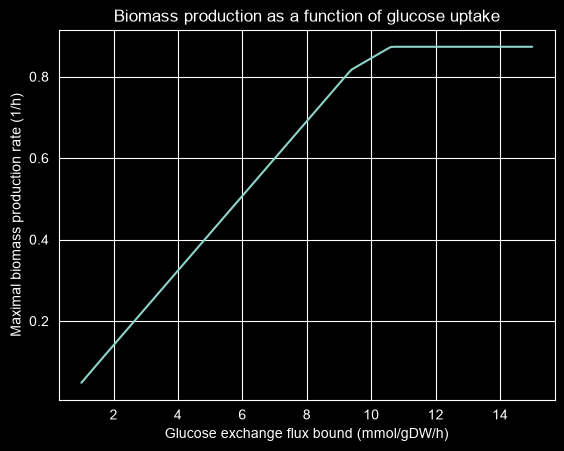

0.873286245858238


In [42]:
glucose_bounds = np.arange(1, 15.1, 0.1)
growth_rates = []

glucose = model.reactions.get_by_id("EX_glc__D_e")

for bound in glucose_bounds:
    glucose.lower_bound = -bound
    solution = model.optimize()
    growth_rates.append(solution.objective_value)

plt.plot(glucose_bounds, growth_rates)
plt.xlabel("Glucose exchange flux bound (mmol/gDW/h)")
plt.ylabel("Maximal biomass production rate (1/h)")
plt.title("Biomass production as a function of glucose uptake")

plt.show()
plateau_value = max(growth_rates)
print(plateau_value)

b) The growth rate does not increase indefinitely with increasing glucose exchange flux bound. The maximal biomass production rate first increases almost linearly as the glucose uptake bound increases, meaning that the glucose availability is limiting growth in this range. However, at about 10.62 mmol/gDW/h, the curve reaches a plateau of 0.87 $h^{-1}$ approx. Beyond this point, allowing more glucose uptake does not increase the predicted growth rate, indicating that glucose is no longer the limiting factor and that another constraint in the enzyme activity-constrained metabolic model becomes limiting.

In [43]:
for bound in [5, 10, 14]:
    glucose.lower_bound = -bound
    solution = model.optimize()
    print("Glucose bound:", bound)
    for reaction in model.exchanges:
        if abs(solution.fluxes[reaction.id]) > 1e-6:
            print("  ", reaction.id, round(solution.fluxes[reaction.id], 3))

Glucose bound: 5
   EX_co2_e 12.314
   EX_glc__D_e -5.0
   EX_h_e 8.337
   EX_h2o_e 15.341
   EX_nh4_e -2.266
   EX_o2_e -11.834
   EX_pi_e -1.529
Glucose bound: 10
   EX_ac_e 1.252
   EX_co2_e 21.527
   EX_glc__D_e -10.0
   EX_h_e 18.207
   EX_h2o_e 27.684
   EX_nh4_e -4.609
   EX_o2_e -20.55
   EX_pi_e -3.109
Glucose bound: 14
   EX_ac_e 2.5
   EX_co2_e 21.56
   EX_glc__D_e -10.62
   EX_h_e 20.018
   EX_h2o_e 27.921
   EX_nh4_e -4.762
   EX_o2_e -20.55
   EX_pi_e -3.213


c) In the second part acetate exchange (EX_ac_e) reaction becomes active. At a bound of 5 no acetate is secreted while at a bound of 10 about 1.25 mmol/gDW/hour is secreted. At the plateau it stays at 2.5. Since oxygen update is limited, the extra glucose cannot be fully utilized and part of the carbon is then secreted as acetate.
